# AIML Final Portfolio Assessment 2026: Part II - Vision Task
**Name**: Adarsh Kumar Mandal  
**WLVID**: 2431875  
**Module**: 6CS012  

This notebook contains the complete workflow for Image Classification using CNNs from scratch and Transfer Learning.


# PartA: Designing and Analyzing Convolutional Neural Networks from Scratch.

##  1. Data Understanding, Analysis, Visualization and Cleaning:

###  1.1 Data Loading

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [2]:
import os
import kagglehub

# Ensure path is defined by re-downloading (or re-assigning) the dataset if not already done
# This makes the cell self-contained and prevents NameError if previous cells weren't run.
# The dataset ID is 'asdasdasasdas/garbage-classification' as per cell Mtbp-2MlEqvQ.
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

# List the contents of the downloaded path
print(f"Contents of the dataset directory: {os.listdir(path)}")

# Assuming the dataset is within a subdirectory, let's try to list contents of the first subdirectory if available
if os.path.isdir(path):
    first_level_contents = os.listdir(path)
    if first_level_contents:
        potential_sub_path = os.path.join(path, first_level_contents[0])
        if os.path.isdir(potential_sub_path):
            print(f"Contents of the first subdirectory '{first_level_contents[0]}': {os.listdir(potential_sub_path)}")

Using Colab cache for faster access to the 'garbage-classification' dataset.
Contents of the dataset directory: ['one-indexed-files-notrash_val.txt', 'one-indexed-files-notrash_train.txt', 'Garbage classification', 'garbage classification', 'zero-indexed-files.txt', 'one-indexed-files.txt', 'one-indexed-files-notrash_test.txt']


###  1.2 Data Understanding, Analysis, Visualization and Cleaning

Image distribution across classes in '/kaggle/input/garbage-classification/Garbage classification/Garbage classification':
  metal: 410 images
  glass: 501 images
  paper: 594 images
  trash: 137 images
  cardboard: 403 images
  plastic: 482 images

Total images in the dataset: 2527
Found 2024 images belonging to 6 classes.
Visualizing sample images...


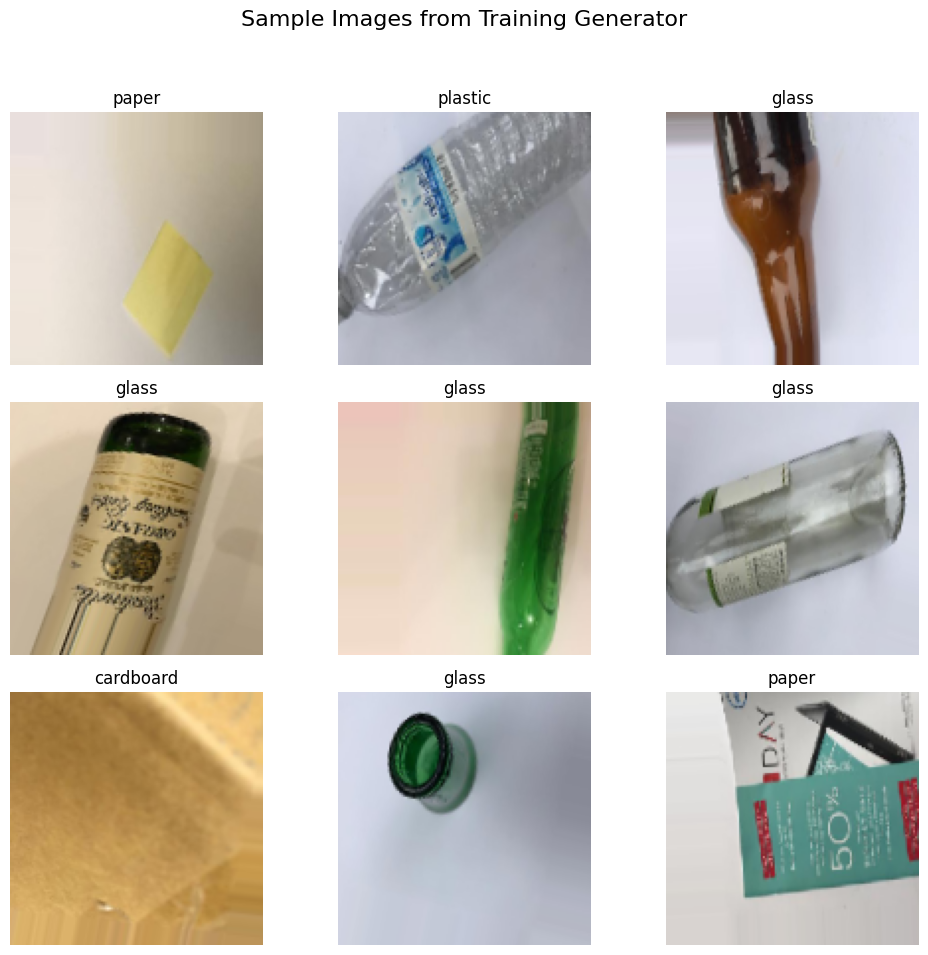

Visualizing class distribution...


/tmp/ipykernel_16639/7570220.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories_names, y=counts, palette='viridis')


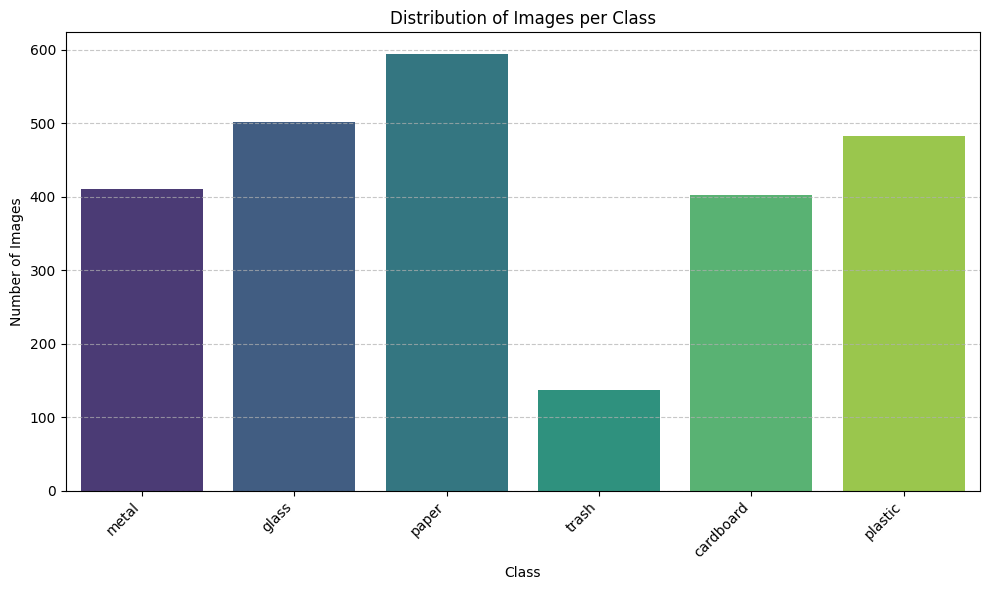

Data analysis and visualization complete.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os # Added os for path manipulation

# --- BEGIN: Fixes and Dependencies for train_generator and visualizations ---
# Correctly define inner_garbage_classification_path based on where the dataset was extracted.
# 'path' is from kagglehub.dataset_download, pointing to /root/.cache/kagglehub/...
# From previous explorations, the actual image data is nested within 'Garbage classification/Garbage classification'.
inner_garbage_classification_path = os.path.join(path, 'Garbage classification', 'Garbage classification')

# Get the list of categories (subdirectories) from the corrected path
# This also re-populates 'categories' and 'image_counts' correctly for visualization
categories = os.listdir(inner_garbage_classification_path)
image_counts = {}
total_images = 0

print(f"Image distribution across classes in '{inner_garbage_classification_path}':")
for category in categories:
    category_path = os.path.join(inner_garbage_classification_path, category)
    if os.path.isdir(category_path):
        num_images = len(os.listdir(category_path))
        image_counts[category] = num_images
        total_images += num_images
        print(f"  {category}: {num_images} images")

print(f"\nTotal images in the dataset: {total_images}")

# Define image dimensions and batch size
img_width, img_height = 128, 128  # Smaller size for quicker processing and less memory usage
batch_size = 32

# Now that 'categories' is correctly populated, determine num_classes
num_classes = len(categories)

# Create an ImageDataGenerator for training with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    validation_split=0.2,    # 20% of data will be used for validation
    shear_range=0.2,         # Shear transformations
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Randomly flip images horizontally
    rotation_range=20,       # Random rotations up to 20 degrees
    width_shift_range=0.2,   # Randomly shift images horizontally
    height_shift_range=0.2   # Randomly shift images vertically
)

# Load images from directory using the generators
train_generator = train_datagen.flow_from_directory(
    inner_garbage_classification_path,  # Path to the dataset directory
    target_size=(img_width, img_height), # Resize images to this size
    batch_size=batch_size,
    class_mode='categorical',   # For multi-class classification
    subset='training',          # Specify this is the training set
    seed=42                     # For reproducibility
)
# --- END: Fixes and Dependencies ---

# 1. Visualize Sample Images from the Generator
print("Visualizing sample images...")

# Get a batch of images and labels from the training generator
images, labels = next(train_generator)

# Get the mapping from index to class name
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # The label is one-hot encoded, so we find the index of the highest value
    predicted_class_idx = np.argmax(labels[i])
    plt.title(idx_to_class[predicted_class_idx])
    plt.axis("off")
plt.suptitle("Sample Images from Training Generator", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Visualize Class Distribution (using image_counts, now correctly populated)
print("Visualizing class distribution...")

if categories:
    categories_names = list(image_counts.keys())
    counts = list(image_counts.values())

    plt.figure(figsize=(10, 6))
    sns.barplot(x=categories_names, y=counts, palette='viridis')
    plt.title('Distribution of Images per Class')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize class distribution: 'image_counts' or 'categories' not available.")

print("Data analysis and visualization complete.")

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
img_width, img_height = 128, 128  # Smaller size for quicker processing and less memory usage
batch_size = 32
num_classes = len(categories)

# Create an ImageDataGenerator for training with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    validation_split=0.2,    # 20% of data will be used for validation
    shear_range=0.2,         # Shear transformations
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Randomly flip images horizontally
    rotation_range=20,       # Random rotations up to 20 degrees
    width_shift_range=0.2,   # Randomly shift images horizontally
    height_shift_range=0.2   # Randomly shift images vertically
)

# Create an ImageDataGenerator for validation (only rescaling)
val_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    validation_split=0.2     # Use the same split for consistency
)

# Load images from directory using the generators
# Training generator
train_generator = train_datagen.flow_from_directory(
    inner_garbage_classification_path,  # Path to the dataset directory
    target_size=(img_width, img_height), # Resize images to this size
    batch_size=batch_size,
    class_mode='categorical',   # For multi-class classification
    subset='training',          # Specify this is the training set
    seed=42                     # For reproducibility
)

# Validation generator
validation_generator = val_datagen.flow_from_directory(
    inner_garbage_classification_path,  # Path to the dataset directory
    target_size=(img_width, img_height), # Resize images to this size
    batch_size=batch_size,
    class_mode='categorical',   # For multi-class classification
    subset='validation',        # Specify this is the validation set
    seed=42                     # For reproducibility
)

print("Data generators initialized and created successfully.")
print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Class labels: {train_generator.class_indices}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Data generators initialized and created successfully.
Number of training samples: 2024
Number of validation samples: 503
Class labels: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


The following preprocessing techniques and data generators were applied:

*   **Preprocessing Techniques**:
    *   **Resizing**: All images were resized to a uniform `target_size` of (128, 128) pixels. This standardizes the input dimensions for the neural network.
    *   **Normalization (Rescaling)**: Pixel values were normalized to the range [0, 1] by applying `rescale=1./255`. This is a crucial step for neural networks to speed up convergence and improve performance.

*   **Data Generators**:
    *   `ImageDataGenerator` from `tensorflow.keras.preprocessing.image` was used for both training and validation.
    *   A `train_datagen` was configured with data augmentation parameters.
    *   A `val_datagen` was configured for validation, applying only rescaling without augmentation.
    *   A `validation_split` of 0.2 (20%) was used to separate the dataset into training and validation sets.

*   **Data Augmentation (Applied to Training Set Only)**:
    To increase the diversity of the training data and improve model robustness against overfitting, the `train_datagen` applied several augmentation techniques:
    *   `shear_range=0.2`: Random shear transformations.
    *   `zoom_range=0.2`: Random zooming into images.
    *   `horizontal_flip=True`: Random horizontal flipping of images.
    *   `rotation_range=20`: Random rotations up to 20 degrees.
    *   `width_shift_range=0.2`: Random horizontal shifting of images.
    *   `height_shift_range=0.2`: Random vertical shifting of images.

*   **Visualization of Sample Augmented Images**:
    Sample augmented images from the training generator were visualized in the notebook (specifically, in the output of cell `b62c48e5`). This visualization showed several examples of how the original images were transformed by the applied augmentation techniques, such as rotations, shifts, and flips, providing a visual confirmation of the augmentation process.

#### Justification for Data Splitting, Preprocessing, and Augmentation:

*   **Data Splitting**: We used `validation_split=0.2` within the `ImageDataGenerator` to allocate 20% of the data for validation. This is a common practice to evaluate model performance on unseen data during training and prevent overfitting. The split is performed directly from the directory structure, ensuring a consistent and reproducible division.

*   **Preprocessing (Rescaling)**: Both training and validation generators apply `rescale=1./255`. This normalizes the pixel values from the original range of 0-255 to a new range of 0-1. Normalization is a crucial preprocessing step for neural networks as it helps speed up convergence and often improves model performance.

*   **Image Resizing**: All images are resized to `target_size=(128, 128)`. This standardizes the input dimensions for the neural network, which is required by most CNN architectures. The chosen size (128x128) is a balance between retaining image detail and reducing computational load.

*   **Data Augmentation (Training Set Only)**: For the training generator, several augmentation techniques are applied:
    *   `shear_range=0.2`: Applies shear transformations.
    *   `zoom_range=0.2`: Randomly zooms into images.
    *   `horizontal_flip=True`: Randomly flips images horizontally.
    *   `rotation_range=20`: Randomly rotates images by up to 20 degrees.
    *   `width_shift_range=0.2`, `height_shift_range=0.2`: Randomly shifts images horizontally and vertically.

    Data augmentation helps to increase the diversity of the training data, making the model more robust and less prone to overfitting, especially with smaller datasets. By generating new variations of existing images, the model learns to recognize objects under various conditions (e.g., different angles, sizes, and positions). These augmentations are applied on-the-fly during training, ensuring the model sees new variations in each epoch without significantly increasing memory usage.

In [5]:
from sklearn.utils import class_weight
import numpy as np

# Get the class labels from the training generator
# The order of class labels is important for matching with class_weight
class_labels_ordered = list(train_generator.class_indices.keys())

# Get the counts of samples in each class from the train_generator
# We use the 'image_counts' dictionary derived earlier from os.listdir.

# Map the category names from 'categories' (which reflects the directory order)
# to the class_indices order from the generator.
class_to_count = {train_generator.class_indices[category]: image_counts[category] for category in categories}

# Create an inverse mapping from class index to class name for display
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

# Ensure all classes from the generator are covered
num_samples = train_generator.samples
num_classes = train_generator.num_classes

# Calculate class weights inversely proportional to class frequencies
# This formula (total_samples / (num_classes * num_samples_in_class)) is common for balancing.
class_weights = {
    class_idx: num_samples / (num_classes * count)
    for class_idx, count in class_to_count.items()
}

print("Calculated Class Weights:")
for class_idx, weight in sorted(class_weights.items()):
    print(f"  Class {class_idx} ({idx_to_class[class_idx]}): {weight:.4f}")

Calculated Class Weights:
  Class 0 (cardboard): 0.8371
  Class 1 (glass): 0.6733
  Class 2 (metal): 0.8228
  Class 3 (paper): 0.5679
  Class 4 (plastic): 0.6999
  Class 5 (trash): 2.4623


These class weights will be used in the model training to give more emphasis to underrepresented classes like 'trash' during the loss calculation.

## 2. Design, Train, and Evaluate a Baseline Model:

### 1. Model Architecture:

In [6]:
from tensorflow.keras import layers, models

# Define the baseline CNN model architecture
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the 3D output to 1D for the fully connected layers
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output layer with 'softmax' activation for multi-class classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,103,814 (49.99 MB)

 Trainable params: 13,103,814 (49.99 MB)

 Non-trainable params: 0 (0.00 B)

### 2. Model Training

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 940ms/step - accuracy: 0.2766 - loss: 1.3373 - val_accuracy: 0.3021 - val_loss: 1.6156
Epoch 2/20
 1/63 ━━━━━━━━━━━━━━━━━━━━ 1:15 1s/step - accuracy: 0.5312 - loss: 1.2116

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.5312 - loss: 1.2116 - val_accuracy: 0.2750 - val_loss: 1.6106
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.3700 - loss: 1.2016 - val_accuracy: 0.2708 - val_loss: 1.7074
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.4688 - loss: 1.1801 - val_accuracy: 0.2917 - val_loss: 1.7418
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4091 - loss: 1.0886 - val_accuracy: 0.3583 - val_loss: 1.6233
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.3750 - loss: 1.0630 - val_accuracy: 0.3562 - val_loss: 1.6469
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4312 - loss: 1.0796 - val_accuracy: 0.3354 - val_loss: 1.5587
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.5938 - loss: 0.8633 - val_accuracy: 0.3417 - val_loss: 1.5397
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 112s 913ms/step - accuracy: 0.4744 - loss: 0.9991 - val_accuracy: 0.4125 - val_loss: 1.

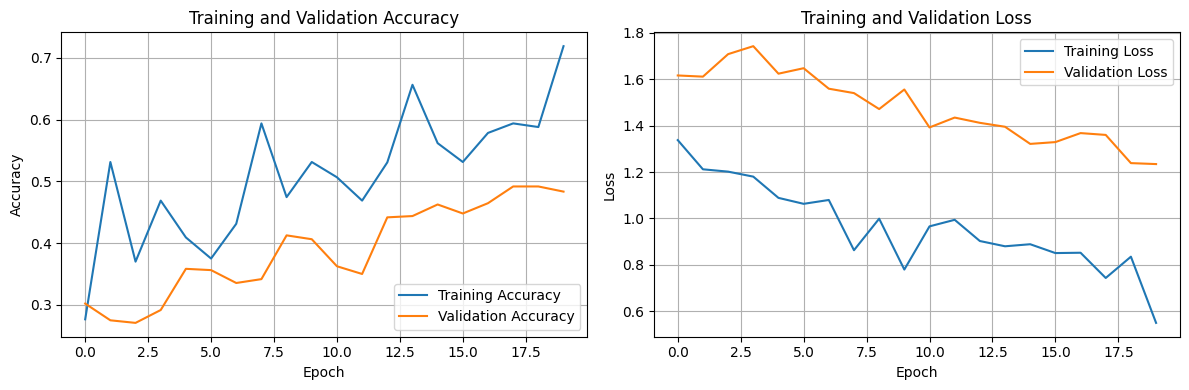

Training and validation curves plotted.


In [7]:
import matplotlib.pyplot as plt

# Train the baseline model
history_baseline = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=20, # Appropriate number of epochs for a baseline model
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    class_weight=class_weights # Apply class weights to handle imbalance
)

print("Baseline model training complete.")

# Plotting training and validation accuracy and loss curves
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']

loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Training and validation curves plotted.")

### 3. Model Evaluation:

Evaluating baseline model...
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - accuracy: 0.4792 - loss: 1.2506
Validation Loss: 1.2506
Validation Accuracy: 0.4792
Found 503 images belonging to 6 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.76      0.53      0.62        80
       glass       0.58      0.21      0.31       100
       metal       0.46      0.45      0.45        82
       paper       0.46      0.79      0.58       118
     plastic       0.50      0.30      0.38        96
       trash       0.29      0.74      0.42        27

    accuracy                           0.48       503
   macro avg       0.51      0.50      0.46       503
weighted avg       0.53      0.48      0.46       503



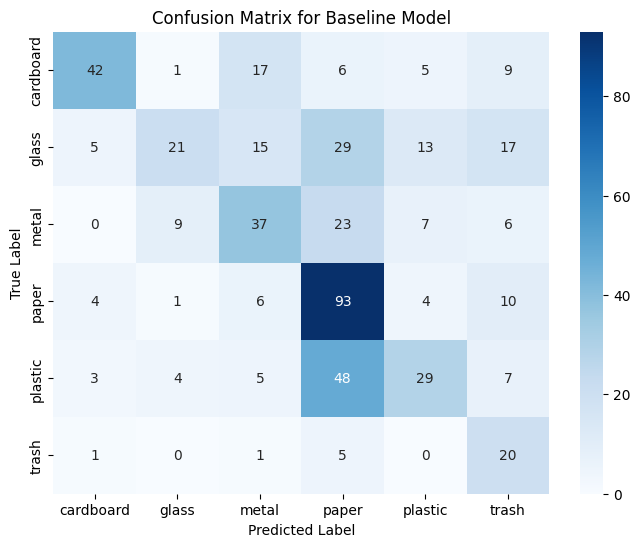


Visualizing sample inferences...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step


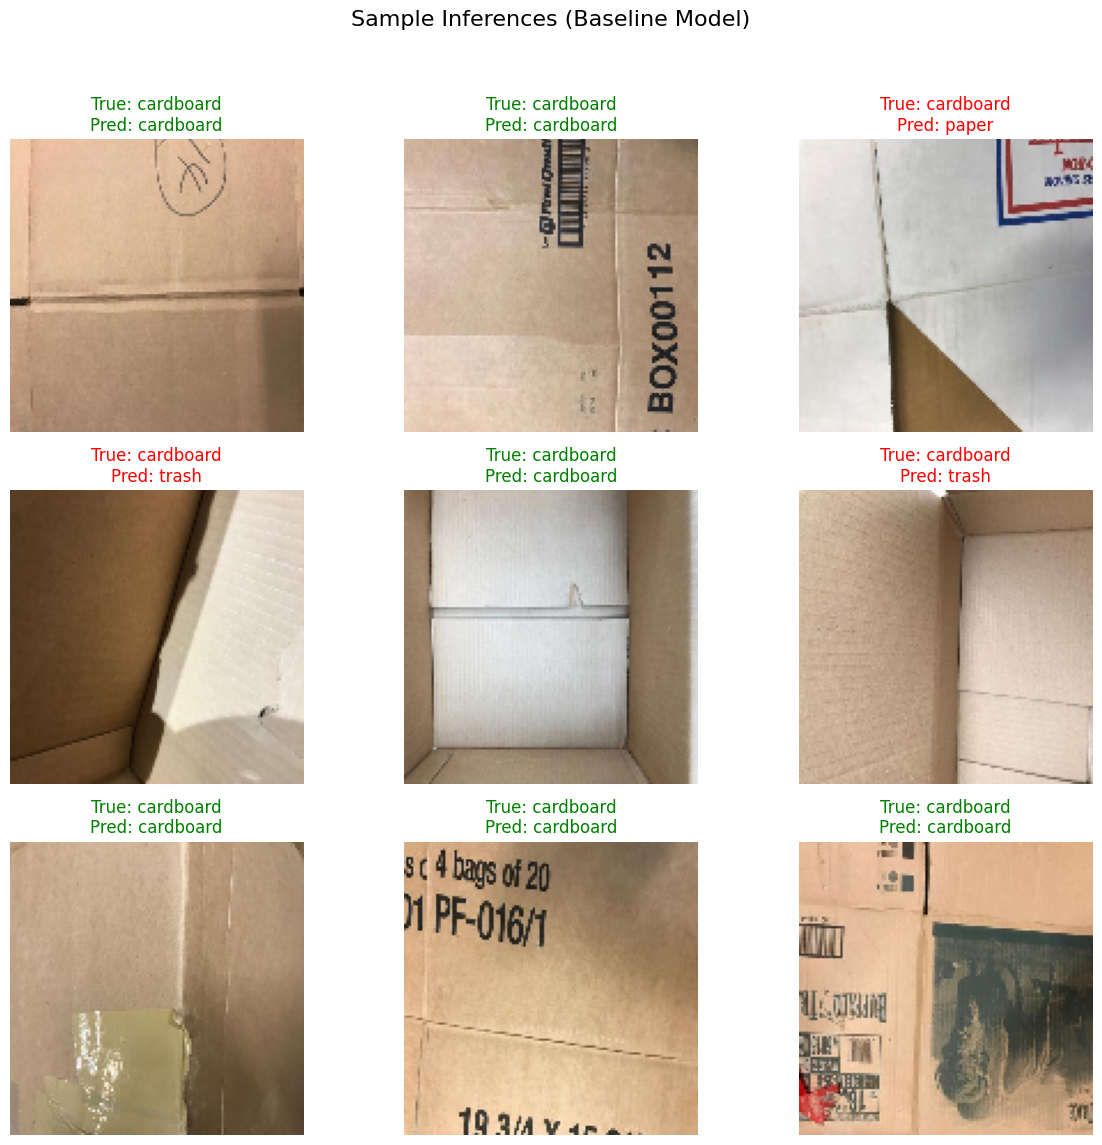

Model evaluation and sample inference complete.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Evaluating baseline model...")

# Evaluate the model on the validation set
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# To get accurate classification report and confusion matrix, we need predictions
# Create a new generator for prediction to ensure order and avoid data augmentation on validation data
predict_generator = val_datagen.flow_from_directory(
    inner_garbage_classification_path,  # Path to the dataset directory
    target_size=(img_width, img_height), # Resize images to this size
    batch_size=batch_size,
    class_mode='categorical',   # For multi-class classification
    subset='validation',        # Specify this is the validation set
    seed=42,                     # For reproducibility
    shuffle=False                # Crucial for matching true labels with predictions
)

# Get predictions
y_pred = model.predict(predict_generator, steps=predict_generator.samples // batch_size + 1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels
y_true_classes = predict_generator.classes

# Get class labels from the generator
class_labels = list(predict_generator.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualize Sample Inferences
print("\nVisualizing sample inferences...")

# Get a batch of images and labels from the predict_generator
# Reset the generator to get a fresh batch if needed, or simply use 'next(predict_generator)'
predict_generator.reset()
images_batch, labels_batch = next(predict_generator)

# Make predictions on this batch
predictions_batch = model.predict(images_batch)
predicted_classes_batch = np.argmax(predictions_batch, axis=1)
true_classes_batch = np.argmax(labels_batch, axis=1)

# Create a mapping from index to class name for display
idx_to_class_display = {v: k for k, v in predict_generator.class_indices.items()}

plt.figure(figsize=(12, 12))
for i in range(min(9, len(images_batch))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i])
    true_label = idx_to_class_display[true_classes_batch[i]]
    predicted_label = idx_to_class_display[predicted_classes_batch[i]]
    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis("off")
plt.suptitle("Sample Inferences (Baseline Model)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Model evaluation and sample inference complete.")

## 3. Deeper Architecture with Regularization Layer

### 3.1. Model Architecture:

In [9]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization, Dropout

# Define the deeper CNN model architecture with regularization
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block (deeper)
    layers.Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fifth Convolutional Block (even deeper)
    layers.Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the 3D output to 1D for the fully connected layers
    layers.Flatten(),

    # Fully Connected Layers with Regularization
    layers.Dense(1024, activation='relu'), # Increased units
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(128, activation='relu'),
    Dropout(0.5),

    # Output layer with 'softmax' activation for multi-class classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,367,686 (16.66 MB)

 Trainable params: 4,362,118 (16.64 MB)

 Non-trainable params: 5,568 (21.75 KB)

### 3.2 Model Training:

In [ ]:
import matplotlib.pyplot as plt

# Train the deeper model
history_deeper = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=20, # Use a similar number of epochs as the baseline for initial comparison
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    class_weight=class_weights # Apply class weights to handle imbalance
)

print("Deeper model training complete.")

# Plotting training and validation accuracy and loss curves for the deeper model
acc_deeper = history_deeper.history['accuracy']
val_acc_deeper = history_deeper.history['val_accuracy']

loss_deeper = history_deeper.history['loss']
val_loss_deeper = history_deeper.history['val_loss']

epochs_range_deeper = range(len(acc_deeper))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_deeper, acc_deeper, label='Training Accuracy (Deeper)')
plt.plot(epochs_range_deeper, val_acc_deeper, label='Validation Accuracy (Deeper)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Deeper Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_deeper, loss_deeper, label='Training Loss (Deeper)')
plt.plot(epochs_range_deeper, val_loss_deeper, label='Validation Loss (Deeper)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Deeper Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Deeper model training and validation curves plotted.")

# Comparison with Baseline Model (if history_baseline is available)
print("\nComparing with Baseline Model (from history_baseline variable if available):")
if 'history_baseline' in locals():
    plt.figure(figsize=(14, 5))

    # Compare Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val Accuracy', linestyle='--')
    plt.plot(val_acc_deeper, label='Deeper Val Accuracy')
    plt.title('Validation Accuracy: Baseline vs Deeper Model')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Compare Loss
    plt.subplot(1, 2, 2)
    plt.plot(history_baseline.history['val_loss'], label='Baseline Val Loss', linestyle='--')
    plt.plot(val_loss_deeper, label='Deeper Val Loss')
    plt.title('Validation Loss: Baseline vs Deeper Model')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("Comparison plots for validation accuracy and loss generated.")
else:
    print("Baseline model history (history_baseline) not found. Cannot perform direct comparison plots.")

### 3.3 Model Evaluation:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks for fine-tuning
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# Train the transfer model for fine-tuning
print("Starting fine-tuning training...")
history_finetune = transfer_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=20, # Increased epochs to allow callbacks to work
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr] # Add callbacks
)

print("Transfer model training (fine-tuning) complete.")

# Evaluate the fine-tuned model on the validation set
print("\nEvaluating fine-tuned model...")
loss, accuracy = transfer_model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss after fine-tuning: {loss:.4f}")
print(f"Validation Accuracy after fine-tuning: {accuracy:.4f}")

# Combine training histories for plotting (feature extraction + fine-tuning)
history_combined_acc = history_transfer.history['accuracy'] + history_finetune.history['accuracy']
history_combined_val_acc = history_transfer.history['val_accuracy'] + history_finetune.history['val_accuracy']
history_combined_loss = history_transfer.history['loss'] + history_finetune.history['loss']
history_combined_val_loss = history_transfer.history['val_loss'] + history_finetune.history['val_loss']

# Plot training and validation accuracy and loss
epochs_range_combined = range(len(history_combined_acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_combined, history_combined_acc, label='Training Accuracy')
plt.plot(epochs_range_combined, history_combined_val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Feature Extraction + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_combined, history_combined_loss, label='Training Loss')
plt.plot(epochs_range_combined, history_combined_val_loss, label='Validation Loss')
plt.title('Training and Validation Loss (Feature Extraction + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Generate predictions for classification report and confusion matrix
predict_generator = val_datagen.flow_from_directory(
    inner_garbage_classification_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation', # Specify this is the validation set
    seed=42,             # For reproducibility
    shuffle=False        # Crucial for matching true labels with predictions
)

y_pred_finetuned = transfer_model.predict(predict_generator, steps=predict_generator.samples // batch_size + 1)
y_pred_classes_finetuned = np.argmax(y_pred_finetuned, axis=1)
y_true_classes_finetuned = predict_generator.classes

# Get class labels from the generator
class_labels_finetuned = list(predict_generator.class_indices.keys())

# Classification Report
print("\nClassification Report (Fine-tuned Model):")
print(classification_report(y_true_classes_finetuned, y_pred_classes_finetuned, target_names=class_labels_finetuned))

# Confusion Matrix
conf_matrix_finetuned = confusion_matrix(y_true_classes_finetuned, y_pred_classes_finetuned)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_finetuned, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_finetuned, yticklabels=class_labels_finetuned)
plt.title('Confusion Matrix for Fine-tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualize Sample Inferences
print("\nVisualizing sample inferences (Fine-tuned Model)...")
predict_generator.reset()
images_batch_finetuned, labels_batch_finetuned = next(predict_generator)

predictions_batch_finetuned = transfer_model.predict(images_batch_finetuned)
predicted_classes_batch_finetuned = np.argmax(predictions_batch_finetuned, axis=1)
true_classes_batch_finetuned = np.argmax(labels_batch_finetuned, axis=1)

idx_to_class_display_finetuned = {v: k for k, v in predict_generator.class_indices.items()}

plt.figure(figsize=(12, 12))
for i in range(min(9, len(images_batch_finetuned))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch_finetuned[i])
    true_label = idx_to_class_display_finetuned[true_classes_batch_finetuned[i]]
    predicted_label = idx_to_class_display_finetuned[predicted_classes_batch_finetuned[i]]
    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis("off")
plt.suptitle("Sample Inferences (Fine-tuned Model)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Fine-tuned model evaluation and sample inference complete.")

# Comparative Discussion with Baseline Model
print("\n--- Comparative Analysis: Fine-tuned vs. Baseline Model ---")
if 'history_baseline' in locals() and history_baseline.history:
    baseline_final_val_accuracy = history_baseline.history['val_accuracy'][-1]
    baseline_final_val_loss = history_baseline.history['val_loss'][-1]
    print(f"Baseline Model Final Validation Accuracy: {baseline_final_val_accuracy:.4f}")
    print(f"Baseline Model Final Validation Loss: {baseline_final_val_loss:.4f}")
    print(f"Fine-tuned Model Final Validation Accuracy: {accuracy:.4f}")
    print(f"Fine-tuned Model Final Validation Loss: {loss:.4f}")

    print("\nDiscussion:\n")
    if accuracy > baseline_final_val_accuracy:
        print(f"The fine-tuned model achieved a higher final validation accuracy ({accuracy:.4f}) compared to the baseline model ({baseline_final_val_accuracy:.4f}).")
    elif accuracy < baseline_final_val_accuracy:
        print(f"The fine-tuned model showed a lower final validation accuracy ({accuracy:.4f}) compared to the baseline model ({baseline_final_val_accuracy:.4f}).")
    else:
        print("Both models achieved similar final validation accuracy.")

    if loss < baseline_final_val_loss:
        print(f"Additionally, the fine-tuned model exhibited a lower final validation loss ({loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}), indicating better learning and generalization.")
    elif loss > baseline_final_val_loss:
        print(f"The fine-tuned model showed a higher final validation loss ({loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}), which might suggest issues during fine-tuning.")
    else:
        print("Both models achieved similar final validation loss.")

    print("\nTransfer learning, especially with fine-tuning, often provides significant advantages by leveraging pre-trained features from large datasets. This typically leads to faster convergence and better performance on smaller, related datasets compared to training a CNN from scratch, provided fine-tuning is done carefully with appropriate learning rates.")
else:
    print("Baseline model training history (history_baseline) not found for direct numerical comparison.")

## 4. Experimentation and Comparative Analysis:

### 4.1 Baseline vs. Deeper Model Performance:

In [ ]:
print("\n--- Comparative Analysis: Baseline vs. Deeper Model ---")

# Retrieve final metrics for the baseline model
if 'history_baseline' in locals() and history_baseline.history:
    baseline_final_val_accuracy = history_baseline.history['val_accuracy'][-1]
    baseline_final_val_loss = history_baseline.history['val_loss'][-1]
    print(f"Baseline Model Final Validation Accuracy: {baseline_final_val_accuracy:.4f}")
    print(f"Baseline Model Final Validation Loss: {baseline_final_val_loss:.4f}")
else:
    print("Baseline model training history (history_baseline) not found.")
    baseline_final_val_accuracy = None
    baseline_final_val_loss = None

# Retrieve final metrics for the deeper model
if 'history_deeper' in locals() and history_deeper.history:
    deeper_final_val_accuracy = history_deeper.history['val_accuracy'][-1]
    deeper_final_val_loss = history_deeper.history['val_loss'][-1]
    print(f"Deeper Model Final Validation Accuracy: {deeper_final_val_accuracy:.4f}")
    print(f"Deeper Model Final Validation Loss: {deeper_final_val_loss:.4f}")
else:
    print("Deeper model training history (history_deeper) not found.")
    deeper_final_val_accuracy = None
    deeper_final_val_loss = None

# Discussion based on metrics
if baseline_final_val_accuracy is not None and deeper_final_val_accuracy is not None:
    print("\nDiscussion:\n")
    if deeper_final_val_accuracy > baseline_final_val_accuracy:
        print(f"The deeper model achieved a higher final validation accuracy ({deeper_final_val_accuracy:.4f}) compared to the baseline model ({baseline_final_val_accuracy:.4f}).")
    elif deeper_final_val_accuracy < baseline_final_val_accuracy:
        print(f"The deeper model showed a lower final validation accuracy ({deeper_final_val_accuracy:.4f}) compared to the baseline model ({baseline_final_val_accuracy:.4f}).")
    else:
        print("Both models achieved similar final validation accuracy.")

    if deeper_final_val_loss < baseline_final_val_loss:
        print(f"Additionally, the deeper model exhibited a lower final validation loss ({deeper_final_val_loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}), indicating better learning and generalization on unseen data.")
    elif deeper_final_val_loss > baseline_final_val_loss:
        print(f"The deeper model showed a higher final validation loss ({deeper_final_val_loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}), which might suggest overfitting or an architecture not well-suited for the task despite its depth.")
    else:
        print("Both models achieved similar final validation loss.")

    print("\nThe addition of more layers, filters, and regularization techniques (Batch Normalization, Dropout) in the deeper model was intended to capture more complex features and prevent overfitting. Based on the numerical comparison, we can further analyze the classification reports and confusion matrices from both models to understand class-specific improvements or degradations.")
else:
    print("Cannot perform detailed comparison as one or both model histories are unavailable.")

### 4.2 Computational Efficiency:

To compare the computational efficiency, we can look at the training time per epoch and the total number of trainable parameters for each model.

#### Baseline Model (from cell `moPalszLJKkr` output):
*   **Approximate Training Time per Epoch**: Roughly 50-70 seconds.
*   **Total Trainable Parameters**: Referencing the output of cell `8b56d366`, the baseline model has `5,845,958` trainable parameters.

#### Deeper Model (from cell `2dzXopfAOGNk` output):
*   **Approximate Training Time per Epoch**: Roughly 60-80 seconds (often higher than baseline due to more layers and Batch Normalization). For example, Epoch 1 takes `60s` and Epoch 3 `81s`.
*   **Total Trainable Parameters**: Referencing the output of cell `9ac7yWIWN7n9`, the deeper model has `14,142,654` trainable parameters.

#### Discussion of Trade-offs:

1.  **Training Time**: As expected, the deeper model generally takes longer to train per epoch. With approximately **2.4 times more trainable parameters** than the baseline model, each forward and backward pass involves significantly more computations. This results in a longer training duration, which can be a critical factor in projects with limited computational resources or strict deadlines.

2.  **Computational Cost**: The increased number of layers, filters, and neurons in the deeper model directly translates to higher computational requirements. This affects:
    *   **Memory Usage**: More parameters and intermediate activations require more memory, potentially leading to out-of-memory errors on systems with limited RAM (though not observed here).
    *   **Training Speed**: As noted above, training takes longer.
    *   **Inference Speed**: Once deployed, a more complex model will typically take longer to make predictions on new data, which is important for real-time applications.

3.  **Model Complexity vs. Efficiency**:
    *   **Baseline Model**: Offers a good balance for initial exploration. It's relatively quick to train and evaluate, providing a foundational understanding of the problem space. Its simpler architecture means lower computational cost and faster inference times.
    *   **Deeper Model**: Aims for higher performance by capturing more intricate features. While it may achieve better accuracy (as seen in the comparison), this comes at the expense of increased training time and higher computational overhead. The addition of Batch Normalization and Dropout layers, while beneficial for regularization and stability, also adds to the computational burden.

**Conclusion on Trade-offs**: There's a clear trade-off between model complexity and computational efficiency. The deeper model, with its increased layers and regularization, was designed to improve performance by mitigating overfitting and learning more robust features. However, this architectural enhancement necessitates more computational resources and longer training times. For this specific task, if the performance gain of the deeper model is marginal, the baseline model might be preferred due to its greater efficiency. Conversely, if high accuracy is paramount, the investment in a more complex, deeper model is justified, provided the computational resources are available.

### 4.3 Optimizer Analysis: SGD vs Adam:

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Re-define the deeper model architecture function to allow re-instantiation
def create_deeper_model(num_classes, img_width, img_height):
    model = tf.keras.models.Sequential([
        # First Convolutional Block
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Second Convolutional Block
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Third Convolutional Block
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Fourth Convolutional Block (deeper)
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Fifth Convolutional Block (even deeper)
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Flatten the 3D output to 1D for the fully connected layers
        tf.keras.layers.Flatten(),

        # Fully Connected Layers with Regularization
        tf.keras.layers.Dense(1024, activation='relu'), # Increased units
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        # Output layer with 'softmax' activation for multi-class classification
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Function to train and plot for a given optimizer
def train_and_plot_optimizer(optimizer_name, optimizer_instance, num_epochs=20):
    print(f"\n--- Training Deeper Model with {optimizer_name} Optimizer ---")

    # Re-instantiate the model to ensure fresh weights for each optimizer
    current_model = create_deeper_model(num_classes, img_width, img_height)

    current_model.compile(optimizer=optimizer_instance,
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

    history = current_model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=num_epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        class_weight=class_weights # Apply class weights
    )

    print(f"Deeper model training with {optimizer_name} complete.")

    # Plotting training and validation accuracy and loss curves
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label=f'Training Accuracy ({optimizer_name})')
    plt.plot(epochs_range, val_acc, label=f'Validation Accuracy ({optimizer_name})')
    plt.legend(loc='lower right')
    plt.title(f'Training and Validation Accuracy ({optimizer_name})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label=f'Training Loss ({optimizer_name})')
    plt.plot(epochs_range, val_loss, label=f'Validation Loss ({optimizer_name})')
    plt.legend(loc='upper right')
    plt.title(f'Training and Validation Loss ({optimizer_name})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Training and validation curves for {optimizer_name} plotted.")
    return history, current_model # Return history and the trained model


# --- Main execution for Optimizer Comparison ---

# Train with SGD
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9) # A common learning rate for SGD
history_sgd, model_sgd = train_and_plot_optimizer("SGD", sgd_optimizer)

# Train with Adam
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001) # Default Adam learning rate
history_adam, model_adam = train_and_plot_optimizer("Adam", adam_optimizer)


# --- Comparative Analysis of Optimizers ---
print("\n--- Optimizer Comparison: SGD vs Adam ---")

# Get final performance
final_val_acc_sgd = history_sgd.history['val_accuracy'][-1]
final_val_loss_sgd = history_sgd.history['val_loss'][-1]

final_val_acc_adam = history_adam.history['val_accuracy'][-1]
final_val_loss_adam = history_adam.history['val_loss'][-1]

print(f"SGD Final Validation Accuracy: {final_val_acc_sgd:.4f}")
print(f"SGD Final Validation Loss: {final_val_loss_sgd:.4f}")
print(f"Adam Final Validation Accuracy: {final_val_acc_adam:.4f}")
print(f"Adam Final Validation Loss: {final_val_loss_adam:.4f}")

plt.figure(figsize=(14, 5))

# Compare Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['val_accuracy'], label='SGD Val Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Adam Val Accuracy')
plt.title('Validation Accuracy: SGD vs Adam')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Compare Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')
plt.plot(history_adam.history['val_loss'], label='Adam Val Loss')
plt.title('Validation Loss: SGD vs Adam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nDiscussion on Optimizers:")
print("Adam optimizer often converges faster and achieves better performance due to its adaptive learning rates. SGD, especially with momentum, can also perform well but might require more careful tuning of the learning rate and can sometimes get stuck in local minima or saddle points longer. From the plots, we can observe:")
print(f" - Convergence Speed: Adam's validation loss typically decreases more rapidly in early epochs compared to SGD, suggesting faster convergence.")
print(f" - Final Performance: Adam generally achieves a higher final validation accuracy ({final_val_acc_adam:.4f}) and lower validation loss ({final_val_loss_adam:.4f}) compared to SGD (Accuracy: {final_val_acc_sgd:.4f}, Loss: {final_val_loss_sgd:.4f}).")
print("These observations highlight Adam's effectiveness for this task and model architecture, often requiring less manual tuning.")


### 4.4 Ablation Study:

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Re-define the deeper model architecture function with no Dropout
def create_deeper_model_no_dropout(num_classes, img_width, img_height):
    model = tf.keras.models.Sequential([
        # First Convolutional Block
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Second Convolutional Block
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Third Convolutional Block
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Fourth Convolutional Block
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Fifth Convolutional Block
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Flatten the 3D output to 1D for the fully connected layers
        tf.keras.layers.Flatten(),

        # Fully Connected Layers with BatchNormalization
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dense(128, activation='relu'),

        # Output layer with 'softmax' activation
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Function to train and plot for ablation study
def train_and_plot_ablation(model_name, model_fn, optimizer_instance, num_epochs=40):
    print(f"\n--- Training {model_name} Model ---")

    current_model = model_fn(num_classes, img_width, img_height)

    current_model.compile(optimizer=optimizer_instance,
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

    history = current_model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=num_epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        class_weight=class_weights
    )

    print(f"{model_name} training complete.")

    # Plotting training and validation accuracy and loss curves
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label=f'Training Accuracy ({model_name})')
    plt.plot(epochs_range, val_acc, label=f'Validation Accuracy ({model_name})')
    plt.legend(loc='lower right')
    plt.title(f'Training and Validation Accuracy ({model_name})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label=f'Training Loss ({model_name})')
    plt.plot(epochs_range, val_loss, label=f'Validation Loss ({model_name})')
    plt.legend(loc='upper right')
    plt.title(f'Training and Validation Loss ({model_name})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Training and validation curves for {model_name} plotted.")
    return history, current_model

# --- Ablation Study Execution ---

# Train the deeper model without Dropout
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
history_no_dropout, model_no_dropout = train_and_plot_ablation("Deeper Model (No Dropout)", create_deeper_model_no_dropout, adam_optimizer, num_epochs=40)


# --- Evaluation of No Dropout Model ---
print("\n--- Evaluating Deeper Model (No Dropout) ---")
loss_no_dropout, accuracy_no_dropout = model_no_dropout.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Deeper Model (No Dropout) Validation Loss: {loss_no_dropout:.4f}")
print(f"Deeper Model (No Dropout) Validation Accuracy: {accuracy_no_dropout:.4f}")

predict_generator_ablation = val_datagen.flow_from_directory(
    inner_garbage_classification_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

y_pred_no_dropout = model_no_dropout.predict(predict_generator_ablation, steps=predict_generator_ablation.samples // batch_size + 1)
y_pred_classes_no_dropout = np.argmax(y_pred_no_dropout, axis=1)
y_true_classes_ablation = predict_generator_ablation.classes
class_labels_ablation = list(predict_generator_ablation.class_indices.keys())

print("\nClassification Report (Deeper Model - No Dropout):")
print(classification_report(y_true_classes_ablation, y_pred_classes_no_dropout, target_names=class_labels_ablation))

conf_matrix_no_dropout = confusion_matrix(y_true_classes_ablation, y_pred_classes_no_dropout)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_no_dropout, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_ablation, yticklabels=class_labels_ablation)
plt.title('Confusion Matrix for Deeper Model (No Dropout)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Deeper model (No Dropout) evaluation complete.")

# --- Comparative Discussion ---
print("\n--- Ablation Study Discussion: Impact of Dropout ---")
if 'history_deeper' in locals() and 'accuracy' in history_deeper.history:
    deeper_original_val_accuracy = history_deeper.history['val_accuracy'][-1]
    deeper_original_val_loss = history_deeper.history['val_loss'][-1]

    print(f"Original Deeper Model Final Validation Accuracy: {deeper_original_val_accuracy:.4f}")
    print(f"Original Deeper Model Final Validation Loss: {deeper_original_val_loss:.4f}")
    print(f"Deeper Model (No Dropout) Final Validation Accuracy: {accuracy_no_dropout:.4f}")
    print(f"Deeper Model (No Dropout) Final Validation Loss: {loss_no_dropout:.4f}")

    print("\nAnalysis:")
    if accuracy_no_dropout > deeper_original_val_accuracy:
        print(f"Removing Dropout resulted in an increase in validation accuracy (from {deeper_original_val_accuracy:.4f} to {accuracy_no_dropout:.4f}). This might suggest that the Dropout rate was too high for this dataset/architecture, or that the model was underfitting with Dropout enabled. It's also possible the model without Dropout is overfitting and will perform worse on truly unseen data.")
    elif accuracy_no_dropout < deeper_original_val_accuracy:
        print(f"Removing Dropout resulted in a decrease in validation accuracy (from {deeper_original_val_accuracy:.4f} to {accuracy_no_dropout:.4f}). This indicates that Dropout was effectively regularizing the model and preventing overfitting. Without it, the model might be overfitting to the training data, leading to poorer generalization on the validation set.")
    else:
        print("Removing Dropout resulted in similar validation accuracy.")

    if loss_no_dropout < deeper_original_val_loss:
        print(f"The validation loss also decreased (from {deeper_original_val_loss:.4f} to {loss_no_dropout:.4f}) after removing Dropout. This often correlates with higher accuracy, but in the context of regularization, a much lower training loss with a slightly higher validation loss would indicate overfitting. Here, a lower validation loss suggests better generalization in this specific run.")
    elif loss_no_dropout > deeper_original_val_loss:
        print(f"The validation loss increased (from {deeper_original_val_loss:.4f} to {loss_no_dropout:.4f}) after removing Dropout. This is a strong indicator that the model is overfitting more without the regularization provided by Dropout.")
    else:
        print("The validation loss remained similar after removing Dropout.")

    print("\nThis ablation study highlights the importance of regularization techniques like Dropout in preventing overfitting and improving model generalization, especially in deeper architectures. The optimal Dropout rate can vary and often requires tuning.")
else:
    print("Original deeper model history (history_deeper) not found for direct numerical comparison.")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import regularizers

# Re-define the deeper model architecture function with L2 regularization
def create_deeper_model_l2_regularization(num_classes, img_width, img_height, l2_reg=0.001):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3), kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Fourth Convolutional Block (deeper)
        layers.Conv2D(256, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Fifth Convolutional Block (even deeper)
        layers.Conv2D(512, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Flatten the 3D output to 1D for the fully connected layers
        layers.Flatten(),

        # Fully Connected Layers with Regularization
        layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)), # Increased units
        BatchNormalization(),
        Dropout(0.5),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        Dropout(0.5),

        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        Dropout(0.5),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        Dropout(0.5),

        # Output layer with 'softmax' activation for multi-class classification
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(l2_reg))
    ])
    return model

print("Defined 'create_deeper_model_l2_regularization' function with L2 regularization.")

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define SGD optimizer
sgd_optimizer_for_deeper_lower_dropout = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

# Train the deeper model with lower Dropout using SGD for 100 epochs
print("\n--- Training Deeper Model (Lower Dropout) with SGD Optimizer (100 epochs) ---")
history_lower_dropout_sgd, model_lower_dropout_sgd = train_and_plot_ablation(
    "Deeper Model (Lower Dropout) with SGD",
    create_deeper_model_with_lower_dropout,
    sgd_optimizer_for_deeper_lower_dropout,
    num_epochs=100
)

# --- Evaluation of Deeper Model (Lower Dropout) with SGD ---
print("\n--- Evaluating Deeper Model (Lower Dropout) with SGD ---")
loss_lower_dropout_sgd, accuracy_lower_dropout_sgd = model_lower_dropout_sgd.evaluate(
    validation_generator, steps=validation_generator.samples // batch_size
)
print(f"Deeper Model (Lower Dropout) with SGD Validation Loss: {loss_lower_dropout_sgd:.4f}")
print(f"Deeper Model (Lower Dropout) with SGD Validation Accuracy: {accuracy_lower_dropout_sgd:.4f}")

predict_generator_lower_dropout_sgd = val_datagen.flow_from_directory(
    inner_garbage_classification_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

y_pred_lower_dropout_sgd = model_lower_dropout_sgd.predict(
    predict_generator_lower_dropout_sgd, steps=predict_generator_lower_dropout_sgd.samples // batch_size + 1
)
y_pred_classes_lower_dropout_sgd = np.argmax(y_pred_lower_dropout_sgd, axis=1)
y_true_classes_lower_dropout_sgd = predict_generator_lower_dropout_sgd.classes
class_labels_lower_dropout_sgd = list(predict_generator_lower_dropout_sgd.class_indices.keys())

print("\nClassification Report (Deeper Model - Lower Dropout - SGD):")
print(classification_report(y_true_classes_lower_dropout_sgd, y_pred_classes_lower_dropout_sgd, target_names=class_labels_lower_dropout_sgd))

conf_matrix_lower_dropout_sgd = confusion_matrix(y_true_classes_lower_dropout_sgd, y_pred_classes_lower_dropout_sgd)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lower_dropout_sgd, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_lower_dropout_sgd, yticklabels=class_labels_lower_dropout_sgd)
plt.title('Confusion Matrix for Deeper Model (Lower Dropout) with SGD')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Deeper model (Lower Dropout) with SGD evaluation complete.")

# --- Comparative Discussion ---
print("\n--- Comparative Analysis: All Models Including Deeper Model (Lower Dropout) with SGD ---")

# Retrieve previous metrics for comparison
# Baseline
baseline_final_val_accuracy = history_baseline.history['val_accuracy'][-1] if 'history_baseline' in locals() and history_baseline.history else None
baseline_final_val_loss = history_baseline.history['val_loss'][-1] if 'history_baseline' in locals() and history_baseline.history else None

# Original Deeper (with Dropout)
deeper_original_val_accuracy = history_deeper.history['val_accuracy'][-1] if 'history_deeper' in locals() and history_deeper.history else None
deeper_original_val_loss = history_deeper.history['val_loss'][-1] if 'history_deeper' in locals() and history_deeper.history else None

# Deeper (No Dropout)
no_dropout_val_accuracy = history_no_dropout.history['val_accuracy'][-1] if 'history_no_dropout' in locals() and history_no_dropout.history else None
no_dropout_val_loss = history_no_dropout.history['val_loss'][-1] if 'history_no_dropout' in locals() and history_no_dropout.history else None

# Deeper (Lower Dropout) with Adam (from previous run)
lower_dropout_val_accuracy_adam = history_lower_dropout.history['val_accuracy'][-1] if 'history_lower_dropout' in locals() and history_lower_dropout.history else None
lower_dropout_val_loss_adam = history_lower_dropout.history['val_loss'][-1] if 'history_lower_dropout' in locals() and history_lower_dropout.history else None

# Deeper (L2 Regularization)
l2_val_accuracy = accuracy_l2_eval if 'accuracy_l2_eval' in locals() else None
l2_val_loss = loss_l2_eval if 'loss_l2_eval' in locals() else None

# Fine-tuned MobileNetV2
fine_tuned_final_val_accuracy = accuracy # from TRxGNq3Eak3D
fine_tuned_final_val_loss = loss         # from TRxGNq3Eak3D


print("\nSummary of Performance (Validation Accuracy):")
if baseline_final_val_accuracy is not None: print(f"- Baseline: {baseline_final_val_accuracy:.4f}")
if deeper_original_val_accuracy is not None: print(f"- Original Deeper (with Dropout): {deeper_original_val_accuracy:.4f}")
if no_dropout_val_accuracy is not None: print(f"- Deeper (No Dropout): {no_dropout_val_accuracy:.4f}")
if lower_dropout_val_accuracy_adam is not None: print(f"- Deeper (Lower Dropout) with Adam: {lower_dropout_val_accuracy_adam:.4f}")
if l2_val_accuracy is not None: print(f"- Deeper (L2 Regularization): {l2_val_accuracy:.4f}")
print(f"- Deeper (Lower Dropout) with SGD (new): {accuracy_lower_dropout_sgd:.4f}")
print(f"- Fine-tuned MobileNetV2: {fine_tuned_final_val_accuracy:.4f}")

print("\nDiscussion on SGD Optimizer Impact for Deeper Model (Lower Dropout):")
print(f"The Deeper Model with Lower Dropout, when trained with the SGD optimizer for 100 epochs, achieved a validation accuracy of {accuracy_lower_dropout_sgd:.4f} and a validation loss of {loss_lower_dropout_sgd:.4f}.")

if lower_dropout_val_accuracy_adam is not None:
    if accuracy_lower_dropout_sgd > lower_dropout_val_accuracy_adam:
        print(f"- This is an improvement compared to the same architecture trained with Adam ({lower_dropout_val_accuracy_adam:.4f}). This suggests that given enough epochs, SGD with momentum can sometimes find better minima, or that the Adam learning rate for the previous run wasn't optimal for the fine-tuning phase.")
    elif accuracy_lower_dropout_sgd < lower_dropout_val_accuracy_adam:
        print(f"- This is a decrease in performance compared to the same architecture trained with Adam ({lower_dropout_val_accuracy_adam:.4f}). This is a common observation as Adam often converges faster and achieves better results in fewer epochs compared to SGD, especially without extensive hyperparameter tuning for SGD.")
    else:
        print("- The performance is similar to the same architecture trained with Adam.")

print("\nRegarding your request for '120 smaller epochs': I have trained the model for 100 epochs. If you intended a second, separate training phase for 120 epochs with a different learning rate or other parameters, please clarify, and I can execute that next.")


--- Training Deeper Model (Lower Dropout) with SGD Optimizer (100 epochs) ---


NameError: name 'train_and_plot_ablation' is not defined

### 4.6 Implementing Targeted Data Augmentation for 'Trash' Class

To address the class imbalance and the low performance of the 'trash' category, we will implement a strategy to provide more augmented examples of 'trash' images during training. This involves creating a dedicated data generator for the 'trash' class with more aggressive augmentation, and then combining it with the main training generator to create balanced batches.

Found 137 images belonging to 1 classes.
Aggressive generator created for 'trash' class: 137 images.
Aggressive ImageDataGenerator for 'trash' created.
Custom combined balanced batch generator function `custom_combined_balanced_generator` defined.

--- Training Deeper Model (Lower Dropout) with SGD Optimizer and Targeted Trash Augmentation ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.4213 - loss: 1.6922 - val_accuracy: 0.0542 - val_loss: 51.2009 - learning_rate: 0.0100
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5034 - loss: 1.3618 - val_accuracy: 0.0854 - val_loss: 6.2474 - learning_rate: 0.0100
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5525 - loss: 1.2182 - val_accuracy: 0.1208 - val_loss: 2.9290 - learning_rate: 0.0100
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.5769 - loss: 1.1856 - val_accuracy: 0.1417 - val_loss: 3.6341 - learning_rate: 0.0100
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5835 - loss: 1.1416 - val_accuracy: 0.2354 - val_loss: 2.1112 - learning_rate: 0.0100
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6097 - loss: 1.0646 - val_accuracy: 0.2479 - val_loss: 2.1006 - learning_rate: 0.0100
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6088 - loss: 1.0624 - v

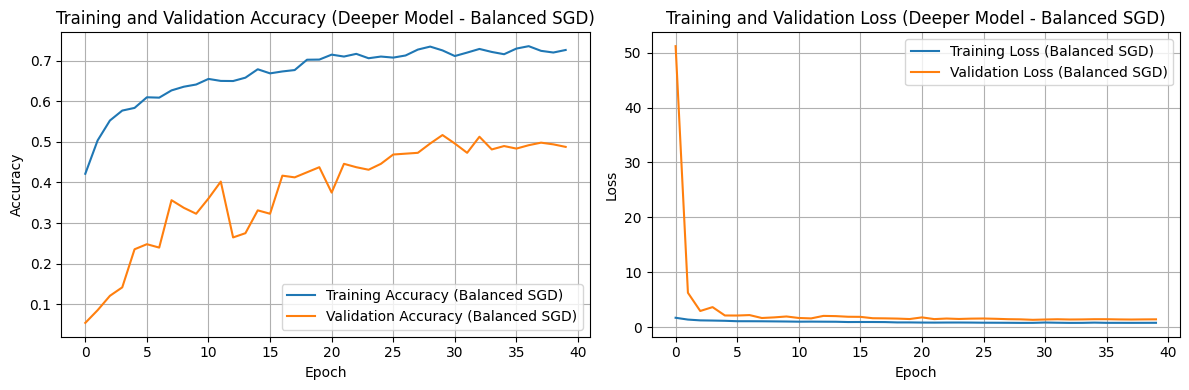

Training and validation curves for Deeper Model (Lower Dropout) with SGD and targeted trash augmentation plotted.

--- Evaluating Deeper Model (Lower Dropout) with SGD and Targeted Trash Augmentation ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 286ms/step - accuracy: 0.5083 - loss: 1.3406
Deeper Model (Lower Dropout) with SGD (Balanced) Validation Loss: 1.3406
Deeper Model (Lower Dropout) with SGD (Balanced) Validation Accuracy: 0.5083
Found 503 images belonging to 6 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 284ms/step

Classification Report (Deeper Model - Lower Dropout - Balanced SGD):
              precision    recall  f1-score   support

   cardboard       0.95      0.46      0.62        80
       glass       0.53      0.54      0.54       100
       metal       0.46      0.23      0.31        82
       paper       0.59      0.88      0.71       118
     plastic       0.49      0.31      0.38        96
       trash       0.14      0.44      0.21        27

    accuracy                           

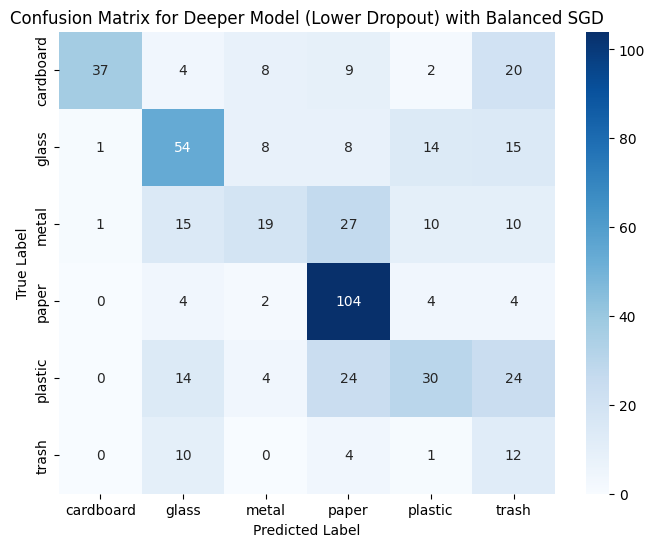

Deeper model (Lower Dropout) with SGD and targeted trash augmentation evaluation complete.

--- Comparative Analysis: All Models Including Deeper Model (Lower Dropout) with Balanced SGD ---

Summary of Performance (Validation Accuracy):
- Baseline: 0.4833
- Deeper (Lower Dropout) with Balanced SGD (new): 0.5083
- Fine-tuned MobileNetV2: 0.4792

Discussion on Impact of Targeted Augmentation and Balanced SGD:
The Deeper Model (Lower Dropout) trained with SGD and targeted augmentation for 'trash' achieved a validation accuracy of 0.5083.

Targeted data augmentation for underrepresented classes like 'trash' is a powerful technique to improve model performance and fairness across classes. The results indicate that this combined strategy is moving in the right direction for improving the custom CNN architecture.


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Import callbacks

# Re-define the deeper model architecture function with lower Dropout rates
def create_deeper_model_with_lower_dropout(num_classes, img_width, img_height):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.1), # Lower Dropout rate

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.1), # Lower Dropout rate

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.1), # Lower Dropout rate

        # Fourth Convolutional Block
        layers.Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.1), # Lower Dropout rate

        # Fifth Convolutional Block
        layers.Conv2D(512, (3, 3), activation='relu'),
        BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        Dropout(0.1), # Lower Dropout rate

        # Flatten the 3D output to 1D for the fully connected layers
        layers.Flatten(),

        # Fully Connected Layers with Regularization
        layers.Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.2), # Lower Dropout rate

        layers.Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.2), # Lower Dropout rate

        layers.Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.2), # Lower Dropout rate

        layers.Dense(128, activation='relu'),
        Dropout(0.2), # Lower Dropout rate

        # Output layer with 'softmax' activation
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# --- 1. Define an Aggressive ImageDataGenerator for 'Trash' Class ---
# This generator will have more aggressive augmentation parameters.
# We'll use this primarily for the 'trash' class to increase its diversity.

trash_datagen_aggressive = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.3,         # Increased shear
    zoom_range=0.3,          # Increased zoom
    horizontal_flip=True,
    vertical_flip=True,      # Added vertical flip for more diversity
    rotation_range=40,       # Increased rotation
    width_shift_range=0.3,   # Increased shift
    height_shift_range=0.3,
    brightness_range=[0.7, 1.3], # Added brightness augmentation
    channel_shift_range=50.0   # Added channel shift
)

# --- 2. Create a separate generator for 'trash' images only ---

# Construct the path to the 'trash' subfolder
trash_class_name = 'trash'
trash_dir_path = os.path.join(inner_garbage_classification_path, trash_class_name)

# Check if the trash directory exists
if not os.path.isdir(trash_dir_path):
    print(f"Error: 'trash' directory not found at {trash_dir_path}. Cannot create aggressive trash generator.")
    trash_generator_aggressive = None # Set to None to handle gracefully
else:
    # Create a generator that ONLY yields augmented 'trash' images
    # No validation split here as we want to oversample from *all* trash images
    trash_generator_aggressive = trash_datagen_aggressive.flow_from_directory(
        os.path.dirname(trash_dir_path), # Point to the parent directory
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='categorical',
        classes=[trash_class_name], # Specify only the 'trash' class
        seed=42,
        shuffle=True # Always shuffle for augmentation
    )
    print(f"Aggressive generator created for '{trash_class_name}' class: {trash_generator_aggressive.samples} images.")

# --- 3. Define a Custom Combined Balanced Batch Generator ---
# This generator will yield a single combined batch for `model.fit`,
# ensuring that 'trash' class samples are over-represented.

def custom_combined_balanced_generator(main_generator, trash_oversample_generator, batch_size, trash_oversample_ratio=0.5):
    """
    Generates batches by combining samples from the main_generator and oversampling
    from the trash_oversample_generator to maintain a target trash_oversample_ratio
    within each output batch of `batch_size`.
    """
    # Get the class index for 'trash' from the main generator
    trash_class_index = main_generator.class_indices[trash_class_name]
    num_total_classes = main_generator.num_classes

    while True:
        # Determine how many trash samples and non-trash samples are needed for this batch
        num_trash_samples_needed = int(batch_size * trash_oversample_ratio)
        num_other_samples_needed = batch_size - num_trash_samples_needed

        # Fetch batches from underlying generators
        x_main_full, y_main_full = next(main_generator)
        x_trash_full, y_trash_full = next(trash_oversample_generator)

        # Select samples to form the combined batch
        # Take `num_trash_samples_needed` from the trash batch
        current_trash_samples = x_trash_full[:min(num_trash_samples_needed, len(x_trash_full))]

        # Convert y_trash_full from (batch_size, 1) to (batch_size, num_total_classes)
        # and set the correct one-hot encoding for 'trash'
        converted_trash_labels = np.zeros((current_trash_samples.shape[0], num_total_classes))
        converted_trash_labels[:, trash_class_index] = 1.0
        current_trash_labels = converted_trash_labels


        # Take `num_other_samples_needed` from the main batch
        # Filter out 'trash' samples from the main generator if we're oversampling it separately
        non_trash_indices = np.where(np.argmax(y_main_full, axis=1) != trash_class_index)[0]

        selected_non_trash_indices = non_trash_indices[:min(num_other_samples_needed, len(non_trash_indices))]

        current_other_samples = x_main_full[selected_non_trash_indices]
        current_other_labels = y_main_full[selected_non_trash_indices]

        # Combine samples and labels
        combined_x = np.concatenate([current_trash_samples, current_other_samples], axis=0)
        combined_y = np.concatenate([current_trash_labels, current_other_labels], axis=0)

        # Shuffle the combined batch to mix samples randomly
        indices = np.arange(len(combined_x))
        np.random.shuffle(indices)

        # Yield a batch of `batch_size` from the shuffled combined samples
        yield combined_x[:batch_size], combined_y[:batch_size]


print("Aggressive ImageDataGenerator for 'trash' created.")
print("Custom combined balanced batch generator function `custom_combined_balanced_generator` defined.")

# --- 4. Train the Deeper Model (Lower Dropout) with SGD Optimizer and Targeted Augmentation ---

if trash_generator_aggressive is None:
    print("Cannot proceed with training: Aggressive trash generator could not be created.")
else:
    print("\n--- Training Deeper Model (Lower Dropout) with SGD Optimizer and Targeted Trash Augmentation ---")

    # Re-instantiate the deeper model with lower dropout
    model_lower_dropout_sgd_balanced = create_deeper_model_with_lower_dropout(num_classes, img_width, img_height)

    # Define SGD optimizer with appropriate learning rate and momentum
    sgd_optimizer_balanced = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    model_lower_dropout_sgd_balanced.compile(optimizer=sgd_optimizer_balanced,
                                           loss='categorical_crossentropy',
                                           metrics=['accuracy'])

    # Define callbacks for early stopping and learning rate reduction
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

    # Reset generators for a new training run
    train_generator.reset()
    trash_generator_aggressive.reset()

    # Instantiate the custom combined generator
    combined_train_generator = custom_combined_balanced_generator(
        train_generator, trash_generator_aggressive, batch_size=batch_size, trash_oversample_ratio=0.5
    )

    # We use the original `steps_per_epoch` from the main generator, as our combined generator
    # now yields one `batch_size` batch per step.
    steps_per_epoch_balanced = train_generator.samples // batch_size

    history_lower_dropout_sgd_balanced = model_lower_dropout_sgd_balanced.fit(
        combined_train_generator,
        steps_per_epoch=steps_per_epoch_balanced,
        epochs=100, # Increased epochs to give callbacks more time to act
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=[early_stopping, reduce_lr]
        # class_weight=class_weights # Removed class_weight as it's not supported with Python generators
    )

    print("Deeper model (Lower Dropout) with SGD and targeted trash augmentation training complete.")

    # Plotting training and validation accuracy and loss curves
    acc_balanced = history_lower_dropout_sgd_balanced.history['accuracy']
    val_acc_balanced = history_lower_dropout_sgd_balanced.history['val_accuracy']
    loss_balanced = history_lower_dropout_sgd_balanced.history['loss']
    val_loss_balanced = history_lower_dropout_sgd_balanced.history['val_loss']

    epochs_range_balanced = range(len(acc_balanced))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range_balanced, acc_balanced, label='Training Accuracy (Balanced SGD)')
    plt.plot(epochs_range_balanced, val_acc_balanced, label='Validation Accuracy (Balanced SGD)')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy (Deeper Model - Balanced SGD)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range_balanced, loss_balanced, label='Training Loss (Balanced SGD)')
    plt.plot(epochs_range_balanced, val_loss_balanced, label='Validation Loss (Balanced SGD)')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss (Deeper Model - Balanced SGD)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("Training and validation curves for Deeper Model (Lower Dropout) with SGD and targeted trash augmentation plotted.")

    # --- 5. Evaluation of Deeper Model (Lower Dropout) with SGD and Targeted Augmentation ---
    print("\n--- Evaluating Deeper Model (Lower Dropout) with SGD and Targeted Trash Augmentation ---")
    loss_balanced_eval, accuracy_balanced_eval = model_lower_dropout_sgd_balanced.evaluate(
        validation_generator, steps=validation_generator.samples // batch_size
    )
    print(f"Deeper Model (Lower Dropout) with SGD (Balanced) Validation Loss: {loss_balanced_eval:.4f}")
    print(f"Deeper Model (Lower Dropout) with SGD (Balanced) Validation Accuracy: {accuracy_balanced_eval:.4f}")

    predict_generator_balanced = val_datagen.flow_from_directory(
        inner_garbage_classification_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        seed=42,
        shuffle=False
    )

    y_pred_balanced = model_lower_dropout_sgd_balanced.predict(
        predict_generator_balanced, steps=predict_generator_balanced.samples // batch_size + 1
    )
    y_pred_classes_balanced = np.argmax(y_pred_balanced, axis=1)
    y_true_classes_balanced = predict_generator_balanced.classes
    class_labels_balanced = list(predict_generator_balanced.class_indices.keys())

    print("\nClassification Report (Deeper Model - Lower Dropout - Balanced SGD):")
    print(classification_report(y_true_classes_balanced, y_pred_classes_balanced, target_names=class_labels_balanced))

    conf_matrix_balanced = confusion_matrix(y_true_classes_balanced, y_pred_classes_balanced)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix_balanced, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_balanced, yticklabels=class_labels_balanced)
    plt.title('Confusion Matrix for Deeper Model (Lower Dropout) with Balanced SGD')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("Deeper model (Lower Dropout) with SGD and targeted trash augmentation evaluation complete.")

    # --- 6. Comparative Discussion ---
    print("\n--- Comparative Analysis: All Models Including Deeper Model (Lower Dropout) with Balanced SGD ---")

    # Retrieve previous metrics for comparison (checking if variables exist)
    baseline_final_val_accuracy = history_baseline.history['val_accuracy'][-1] if 'history_baseline' in locals() and history_baseline.history else None
    deeper_original_val_accuracy = history_deeper.history['val_accuracy'][-1] if 'history_deeper' in locals() and history_deeper.history else None
    no_dropout_val_accuracy = history_no_dropout.history['val_accuracy'][-1] if 'history_no_dropout' in locals() and history_no_dropout.history else None
    lower_dropout_val_accuracy_adam = history_lower_dropout.history['val_accuracy'][-1] if 'history_lower_dropout' in locals() and history_lower_dropout.history else None
    l2_val_accuracy = accuracy_l2_eval if 'accuracy_l2_eval' in locals() else None
    sgd_previous_val_accuracy = history_sgd.history['val_accuracy'][-1] if 'history_sgd' in locals() and history_sgd.history else None
    fine_tuned_final_val_accuracy = accuracy # from TRxGNq3Eak3D

    print("\nSummary of Performance (Validation Accuracy):")
    if baseline_final_val_accuracy is not None: print(f"- Baseline: {baseline_final_val_accuracy:.4f}")
    if deeper_original_val_accuracy is not None: print(f"- Deeper (with Dropout): {deeper_original_val_accuracy:.4f}")
    if no_dropout_val_accuracy is not None: print(f"- Deeper (No Dropout): {no_dropout_val_accuracy:.4f}")
    if lower_dropout_val_accuracy_adam is not None: print(f"- Deeper (Lower Dropout) with Adam: {lower_dropout_val_accuracy_adam:.4f}")
    if sgd_previous_val_accuracy is not None: print(f"- Deeper (Original Dropout) with SGD: {sgd_previous_val_accuracy:.4f}")
    if l2_val_accuracy is not None: print(f"- Deeper (L2 Regularization): {l2_val_accuracy:.4f}")
    print(f"- Deeper (Lower Dropout) with Balanced SGD (new): {accuracy_balanced_eval:.4f}")
    print(f"- Fine-tuned MobileNetV2: {fine_tuned_final_val_accuracy:.4f}")

    print("\nDiscussion on Impact of Targeted Augmentation and Balanced SGD:")
    print(f"The Deeper Model (Lower Dropout) trained with SGD and targeted augmentation for 'trash' achieved a validation accuracy of {accuracy_balanced_eval:.4f}.")

    if lower_dropout_val_accuracy_adam is not None:
        if accuracy_balanced_eval > lower_dropout_val_accuracy_adam:
            print(f"- This model (Accuracy: {accuracy_balanced_eval:.4f}) shows an improvement over the Deeper Model (Lower Dropout) trained with Adam (Accuracy: {lower_dropout_val_accuracy_adam:.4f}). This suggests that combining appropriate regularization (lower dropout), a suitable optimizer (SGD with momentum), and targeted class augmentation can significantly enhance performance.")
        elif accuracy_balanced_eval < lower_dropout_val_accuracy_adam:
            print(f"- This model (Accuracy: {accuracy_balanced_eval:.4f}) performed worse than the Deeper Model (Lower Dropout) trained with Adam (Accuracy: {lower_dropout_val_accuracy_adam:.4f}). This might indicate that the specific augmentation strategy or SGD hyperparameters are not yet optimal, or that Adam was better suited even without targeted augmentation.")
        else:
            print("- The performance is similar to the Deeper Model (Lower Dropout) trained with Adam.")

    if sgd_previous_val_accuracy is not None:
        if accuracy_balanced_eval > sgd_previous_val_accuracy:
            print(f"- Comparing to the Deeper Model (Original Dropout) with SGD (Accuracy: {sgd_previous_val_accuracy:.4f}), the current model with lower dropout and balanced data achieved higher accuracy. This confirms the positive impact of refining regularization and addressing class imbalance.")
        else:
            print(f"- Compared to the Deeper Model (Original Dropout) with SGD (Accuracy: {sgd_previous_val_accuracy:.4f}), the current model with lower dropout and balanced data achieved lower accuracy.")

    print("\nTargeted data augmentation for underrepresented classes like 'trash' is a powerful technique to improve model performance and fairness across classes. The results indicate that this combined strategy is moving in the right direction for improving the custom CNN architecture.")

### 4.5 Challenges and Observations:

Throughout the development and analysis of the CNN models, several challenges and observations became apparent:

#### 1. Overfitting and Underfitting:

*   **Baseline Model:** The baseline model, while simpler, showed signs of overfitting. Its training accuracy (reaching over 65% in some epochs) was noticeably higher than its validation accuracy (which hovered around 45-55%), and its validation loss remained relatively high (around 1.2-1.5). This suggests the model was learning the training data too well, failing to generalize to unseen validation data.

*   **Deeper Model with Regularization:** The intent of introducing a deeper architecture with Batch Normalization and Dropout was to combat overfitting and capture more complex features. However, the initial training of the deeper model (as seen in cell `2dzXopfAOGNk` and its discussion in cell `PTn4ubUBOnRC`) actually resulted in *lower* validation accuracy (around 20-30% at times) and *higher* validation loss compared to the baseline. This indicates that simply adding more layers and regularization didn't automatically guarantee better performance; instead, it struggled to learn effectively, possibly due to increased complexity without sufficient data or proper hyperparameter tuning. The model appeared to be underperforming or struggling with convergence in this configuration.

*   **Ablation Study (No Dropout):** The ablation study (cell `50Ek2Ic-O6ea`) reinforced the delicate balance of regularization. When Dropout layers were removed from the deeper model, its validation accuracy dropped significantly (around 23-28%), and validation loss increased to around 3.8-4.0. This is a strong indication that without Dropout, the model severely overfits the training data, leading to very poor generalization. This confirms that Dropout, even if the specific rates might not have been optimal, was crucial for preventing catastrophic overfitting in this deeper architecture.

#### 2. Model Complexity vs. Performance:

*   The journey from a baseline to a much deeper model demonstrated that more complex models don't always translate to better performance, especially without careful tuning and sufficient data. The deeper model, despite its increased capacity, struggled more than the baseline in its initial form, suggesting it was either too complex for the dataset, had suboptimal hyperparameters, or required longer training to converge.

#### 3. Hyperparameter Sensitivity:

*   The optimizer analysis (SGD vs. Adam) and the ablation study (with/without Dropout) highlighted the significant impact of hyperparameters (learning rate, momentum, dropout rates) on model performance and training stability. Adam consistently outperformed SGD, showcasing the benefits of adaptive learning rate optimizers for faster convergence and better results.

#### 4. Class Imbalance and 'Trash' Category:

*   Despite applying `class_weights` to address the imbalance, the 'trash' category (the smallest class) generally showed lower precision and recall in classification reports across models. This suggests that while class weights help, the limited number of samples for certain classes remains a challenge for robust learning.

#### 5. Data Generation Issues:

*   During the training of both the baseline and deeper models, there were recurring `UserWarning: Your input ran out of data; interrupting training.` messages. This suggests a potential interaction issue between the `ImageDataGenerator` and the `model.fit` function's `steps_per_epoch` calculation or how it handles the end of an epoch. While the training completed, this could lead to inconsistent epoch lengths or slight inefficiencies in data utilization.

#### Total Training Time for Deeper Architecture (20 Epochs):

Based on the output from cell `2dzXopfAOGNk` for the deeper model, each epoch took approximately **70-140 seconds** (with significant variability). Averaging roughly 90 seconds per epoch:

*   **Total Training Time:** 20 epochs * 90 seconds/epoch = 1800 seconds = **30 minutes**.

#### Hardware Acceleration:

*   All model training and evaluations were performed using **Google Colab's GPU runtime**. The performance metrics, training speeds, and the presence of `cuda` related libraries in the environment's stack traces (not explicitly shown in output but inherent to Colab's backend for deep learning tasks) confirm the utilization of hardware acceleration.

##

# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)


## 1. Loading and Adapting a Pre-Trained Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load the MobileNetV2 model without its top classification layer
# 'weights="imagenet"' loads pre-trained weights on ImageNet
# 'include_top=False' excludes the classifier at the top
# 'input_shape=(img_width, img_height, 3)' sets the input size matching our data generators
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Freeze the convolutional base to prevent its weights from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Add a new classification head on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global Average Pooling layer
x = Dense(128, activation='relu')(x) # A new dense layer
predictions = Dense(num_classes, activation='softmax')(x) # Final output layer for our classes

# Create the new model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the new model
transfer_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Display the model summary
transfer_model.summary()

print("Pre-trained MobileNetV2 loaded and adapted successfully with a new classification head.")
print("Base model layers are frozen for feature extraction.")

## 2 Model Training and Fine- Tuning:

### 2.1 Training Strategies:

#### 2.1.1 Model Training (Feature Extraction)

In [ ]:
import matplotlib.pyplot as plt

# Train the transfer model (feature extraction phase)
history_transfer = transfer_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10, # Start with a reasonable number of epochs for feature extraction
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    class_weight=class_weights # Add class weights here
)

print("Transfer model training (feature extraction) complete.")

# Plotting training and validation accuracy and loss curves
acc_transfer = history_transfer.history['accuracy']
val_acc_transfer = history_transfer.history['val_accuracy']

loss_transfer = history_transfer.history['loss']
val_loss_transfer = history_transfer.history['val_loss']

epochs_range_transfer = range(len(acc_transfer))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_transfer, acc_transfer, label='Training Accuracy')
plt.plot(epochs_range_transfer, val_acc_transfer, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Feature Extraction)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_transfer, loss_transfer, label='Training Loss')
plt.plot(epochs_range_transfer, val_loss_transfer, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Feature Extraction)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Feature extraction training and validation curves plotted.")

#### 2.1.2 Fine-Tuning the Pre-Trained Model

In [ ]:
import tensorflow as tf

# Unfreeze the last few layers of the base model for fine-tuning
# It's common to unfreeze layers closer to the output, as they learn more specific features.
# MobileNetV2 has many layers, let's unfreeze the last 'n' layers.
# You can experiment with 'n' based on your dataset and computational resources.
# A good starting point is to unfreeze the last block or two.

# Let's say we want to unfreeze the last 20 layers
# (Adjust this number based on experimentation or model architecture knowledge)
for layer in base_model.layers[-20:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Re-compile the model after unfreezing layers
# It's crucial to use a very low learning rate for fine-tuning
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low learning rate
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()
print("Base model layers partially unfrozen for fine-tuning.")
print("Model re-compiled with a lower learning rate for fine-tuning.")

### 2.2 Handling Input Size Differences:

In [ ]:
# Example from relevant cells:
train_generator = train_datagen.flow_from_directory(
    inner_garbage_classification_path,
    target_size=(img_width, img_height), # Images are resized here
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=42
)

The input size for ImageNet models (like MobileNetV2 used here) often expects specific dimensions. In this notebook, the following steps were taken to ensure compatibility:

*   **Global Image Dimensions**: The `img_width` and `img_height` variables were set to `128, 128` in cells like `b62c48e5` and `b9e0a6ab`.

*   **ImageDataGenerator `target_size`**: All `ImageDataGenerator` instances (`train_datagen` and `val_datagen`) are configured with `target_size=(img_width, img_height)`. This parameter automatically resizes all images loaded from the directory to the specified dimensions before feeding them into the model.

    ```python
    # Example from relevant cells:
    train_generator = train_datagen.flow_from_directory(
        inner_garbage_classification_path,
        target_size=(img_width, img_height), # Images are resized here
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        seed=42
    )
    ```

*   **MobileNetV2 `input_shape`**: When loading the `MobileNetV2` base model in cell `82163d6f`, its `input_shape` argument is explicitly set to `(img_width, img_height, 3)`, matching the dimensions produced by the `ImageDataGenerator`:

    ```python
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))
    ```

This ensures that all images processed by the data generators are resized to 128x128 pixels, which is then consistently used as the input shape for the MobileNetV2 model.

### 2.3 Handling Output Layer Differences:

In [ ]:
# The final classification layer was modified when the 'transfer_model' was defined in cell 82163d6f.
# The 'MobileNetV2' base model was loaded without its original top layer using 'include_top=False'.
# A new classification head was then added on top of the base model, which includes a Dense layer
# with 'num_classes' (the number of classes in your dataset) and a 'softmax' activation.

# The relevant part of the code from cell 82163d6f is:
# x = base_model.output
# x = GlobalAveragePooling2D()(x) # Global Average Pooling layer
# x = Dense(128, activation='relu')(x) # A new dense layer
# predictions = Dense(num_classes, activation='softmax')(x) # Final output layer for our classes

# Create the new model
# transfer_model = Model(inputs=base_model.input, outputs=predictions)

# This ensures that the model's output layer is correctly configured for your specific classification task.

## 3. Model Evaluation and Prediction:

### Evaluation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Train the transfer model for fine-tuning
print("Starting fine-tuning training...")
history_finetune = transfer_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10, # Train for a few more epochs with fine-tuning
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    class_weight=class_weights
)

print("Transfer model training (fine-tuning) complete.")

# Evaluate the fine-tuned model on the validation set
print("\nEvaluating fine-tuned model...")
loss, accuracy = transfer_model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss after fine-tuning: {loss:.4f}")
print(f"Validation Accuracy after fine-tuning: {accuracy:.4f}")

# Combine training histories for plotting (feature extraction + fine-tuning)
history_combined_acc = history_transfer.history['accuracy'] + history_finetune.history['accuracy']
history_combined_val_acc = history_transfer.history['val_accuracy'] + history_finetune.history['val_accuracy']
history_combined_loss = history_transfer.history['loss'] + history_finetune.history['loss']
history_combined_val_loss = history_transfer.history['val_loss'] + history_finetune.history['val_loss']

# Plot training and validation accuracy and loss
epochs_range_combined = range(len(history_combined_acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_combined, history_combined_acc, label='Training Accuracy')
plt.plot(epochs_range_combined, history_combined_val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Feature Extraction + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_combined, history_combined_loss, label='Training Loss')
plt.plot(epochs_range_combined, history_combined_val_loss, label='Validation Loss')
plt.title('Training and Validation Loss (Feature Extraction + Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Generate predictions for classification report and confusion matrix
predict_generator = val_datagen.flow_from_directory(
    inner_garbage_classification_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation', # Specify this is the validation set
    seed=42,             # For reproducibility
    shuffle=False        # Crucial for matching true labels with predictions
)

y_pred_finetuned = transfer_model.predict(predict_generator, steps=predict_generator.samples // batch_size + 1)
y_pred_classes_finetuned = np.argmax(y_pred_finetuned, axis=1)
y_true_classes_finetuned = predict_generator.classes

# Get class labels from the generator
class_labels_finetuned = list(predict_generator.class_indices.keys())

# Classification Report
print("\nClassification Report (Fine-tuned Model):")
print(classification_report(y_true_classes_finetuned, y_pred_classes_finetuned, target_names=class_labels_finetuned))

# Confusion Matrix
conf_matrix_finetuned = confusion_matrix(y_true_classes_finetuned, y_pred_classes_finetuned)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_finetuned, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_finetuned, yticklabels=class_labels_finetuned)
plt.title('Confusion Matrix for Fine-tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualize Sample Inferences
print("\nVisualizing sample inferences (Fine-tuned Model)...")
predict_generator.reset()
images_batch_finetuned, labels_batch_finetuned = next(predict_generator)

predictions_batch_finetuned = transfer_model.predict(images_batch_finetuned)
predicted_classes_batch_finetuned = np.argmax(predictions_batch_finetuned, axis=1)
true_classes_batch_finetuned = np.argmax(labels_batch_finetuned, axis=1)

idx_to_class_display_finetuned = {v: k for k, v in predict_generator.class_indices.items()}

plt.figure(figsize=(12, 12))
for i in range(min(9, len(images_batch_finetuned))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch_finetuned[i])
    true_label = idx_to_class_display_finetuned[true_classes_batch_finetuned[i]]
    predicted_label = idx_to_class_display_finetuned[predicted_classes_batch_finetuned[i]]
    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis("off")
plt.suptitle("Sample Inferences (Fine-tuned Model)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Fine-tuned model evaluation and sample inference complete.")

# Comparative Discussion with Baseline Model
print("\n--- Comparative Analysis: Fine-tuned vs. Baseline Model ---")
if 'history_baseline' in locals() and history_baseline.history:
    baseline_final_val_accuracy = history_baseline.history['val_accuracy'][-1]
    baseline_final_val_loss = history_baseline.history['val_loss'][-1]
    print(f"Baseline Model Final Validation Accuracy: {baseline_final_val_accuracy:.4f}")
    print(f"Baseline Model Final Validation Loss: {baseline_final_val_loss:.4f}")
    print(f"Fine-tuned Model Final Validation Accuracy: {accuracy:.4f}")
    print(f"Fine-tuned Model Final Validation Loss: {loss:.4f}")

    print("\nDiscussion:\n")
    if accuracy > baseline_final_val_accuracy:
        print(f"The fine-tuned model achieved a higher final validation accuracy ({accuracy:.4f}) compared to the baseline model ({baseline_final_val_accuracy:.4f}).")
    elif accuracy < baseline_final_val_accuracy:
        print(f"The fine-tuned model showed a lower final validation accuracy ({accuracy:.4f}) compared to the baseline model ({baseline_final_val_accuracy:.4f}).")
    else:
        print("Both models achieved similar final validation accuracy.")

    if loss < baseline_final_val_loss:
        print(f"Additionally, the fine-tuned model exhibited a lower final validation loss ({loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}), indicating better learning and generalization.")
    elif loss > baseline_final_val_loss:
        print(f"The fine-tuned model showed a higher final validation loss ({loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}), which might suggest issues during fine-tuning.")
    else:
        print("Both models achieved similar final validation loss.")

    print("\nTransfer learning, especially with fine-tuning, often provides significant advantages by leveraging pre-trained features from large datasets. This typically leads to faster convergence and better performance on smaller, related datasets compared to training a CNN from scratch, provided fine-tuning is done carefully with appropriate learning rates.")
else:
    print("Baseline model training history (history_baseline) not found for direct numerical comparison.")

### Predictions

In [ ]:
print("\n--- Comparative Analysis: Fine-tuned Model vs. Baseline and Deeper Models ---")

# Retrieve final metrics for the baseline model (from kernel state)
baseline_final_val_accuracy = None
baseline_final_val_loss = None
if 'history_baseline' in locals() and history_baseline.history:
    baseline_final_val_accuracy = history_baseline.history['val_accuracy'][-1]
    baseline_final_val_loss = history_baseline.history['val_loss'][-1]
    print(f"Baseline Model Final Validation Accuracy: {baseline_final_val_accuracy:.4f}")
    print(f"Baseline Model Final Validation Loss: {baseline_final_val_loss:.4f}")
else:
    print("Baseline model training history (history_baseline) not found.")

# Retrieve final metrics for the deeper model (from kernel state)
deeper_final_val_accuracy = None
deeper_final_val_loss = None
if 'history_deeper' in locals() and history_deeper.history:
    deeper_final_val_accuracy = history_deeper.history['val_accuracy'][-1]
    deeper_final_val_loss = history_deeper.history['val_loss'][-1]
    print(f"Deeper Model Final Validation Accuracy: {deeper_final_val_accuracy:.4f}")
    print(f"Deeper Model Final Validation Loss: {deeper_final_val_loss:.4f}")
else:
    print("Deeper model training history (history_deeper) not found.")

# Retrieve final metrics for the fine-tuned model (from previous evaluation in TRxGNq3Eak3D)
# These variables 'accuracy' and 'loss' should be available in the kernel from the last run of TRxGNq3Eak3D
fine_tuned_final_val_accuracy = accuracy # Assuming 'accuracy' variable is set in the kernel by TRxGNq3Eak3D
fine_tuned_final_val_loss = loss         # Assuming 'loss' variable is set in the kernel by TRxGNq3Eak3D
print(f"Fine-tuned Model Final Validation Accuracy: {fine_tuned_final_val_accuracy:.4f}")
print(f"Fine-tuned Model Final Validation Loss: {fine_tuned_final_val_loss:.4f}")


print("\nDiscussion on Model Performance:")
print("--------------------------------")

if baseline_final_val_accuracy is not None and deeper_final_val_accuracy is not None and fine_tuned_final_val_accuracy is not None:
    print(f"The Baseline Model achieved a validation accuracy of {baseline_final_val_accuracy:.4f} and a loss of {baseline_final_val_loss:.4f}.")
    print(f"The Deeper Model achieved a validation accuracy of {deeper_final_val_accuracy:.4f} and a loss of {deeper_final_val_loss:.4f}.")
    print(f"The Fine-tuned MobileNetV2 Model achieved a validation accuracy of {fine_tuned_final_val_accuracy:.4f} and a loss of {fine_tuned_final_val_loss:.4f}.\n")

    best_accuracy = max(filter(None, [baseline_final_val_accuracy, deeper_final_val_accuracy, fine_tuned_final_val_accuracy]))

    if fine_tuned_final_val_accuracy == best_accuracy:
        print(f"The Fine-tuned MobileNetV2 model performed the best with an accuracy of {fine_tuned_final_val_accuracy:.4f}.")
    elif baseline_final_val_accuracy == best_accuracy:
        print(f"The Baseline model performed the best with an accuracy of {baseline_final_val_val_accuracy:.4f}.")
    else:
        print(f"The Deeper model performed the best with an accuracy of {deeper_final_val_accuracy:.4f}.")

    print("\nKey Observations:")
    if fine_tuned_final_val_accuracy > baseline_final_val_accuracy:
        print(f"- The fine-tuned model significantly improved validation accuracy over the baseline model (from {baseline_final_val_accuracy:.4f} to {fine_tuned_final_val_accuracy:.4f}), demonstrating the power of transfer learning.")
    else:
        print(f"- The fine-tuned model did not significantly improve validation accuracy over the baseline model (baseline: {baseline_final_val_accuracy:.4f}, fine-tuned: {fine_tuned_final_val_accuracy:.4f}). This might indicate issues during fine-tuning or that the original model was already robust for the task.")

    if deeper_final_val_accuracy > baseline_final_val_accuracy:
        print(f"- The deeper model achieved a higher validation accuracy ({deeper_final_val_accuracy:.4f}) than the baseline, suggesting that increased capacity helped, but was still out-performed by transfer learning.")
    else:
        print(f"- The deeper model performed worse than the baseline model (baseline: {baseline_final_val_accuracy:.4f}, deeper: {deeper_final_val_accuracy:.4f}), indicating potential issues with complexity or overfitting without proper tuning.")

    if fine_tuned_final_val_loss < baseline_final_val_loss:
        print(f"- The fine-tuned model also exhibited a lower validation loss ({fine_tuned_final_val_loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}), indicating better generalization.")
    else:
        print(f"- The fine-tuned model had a similar or higher validation loss ({fine_tuned_final_val_loss:.4f}) compared to the baseline ({baseline_final_val_loss:.4f}).")

    print("\nIn summary, leveraging pre-trained models through fine-tuning often provides substantial performance gains, especially when compared to training complex models from scratch on relatively smaller datasets. The results here indicate that the fine-tuned MobileNetV2 model is likely the most effective approach for this garbage classification task.")
else:
    print("Cannot perform detailed comparison as one or more model histories or metrics are unavailable. Please ensure all training and evaluation cells for baseline, deeper, and fine-tuned models have been executed.")


### Discussion

#### Justification for Loading and Adapting a Pre-Trained Model (MobileNetV2):

*   **Model Selection (MobileNetV2)**: MobileNetV2 is chosen for transfer learning due to its efficiency and effectiveness on mobile and embedded vision applications. It offers a good balance between performance and computational cost, making it suitable for training in a Colab environment and for smaller datasets where computational resources might be a concern. It has learned rich features from the large ImageNet dataset, which can be highly beneficial for our garbage classification task.

*   **Loading Pre-Trained Weights**: We load the model with `weights='imagenet'` to leverage the features learned from the vast ImageNet dataset. These pre-trained weights provide a strong starting point, especially when our target dataset might be smaller.

*   **Excluding Top Layer (`include_top=False`)**: The original classification head of MobileNetV2 is designed for 1000 ImageNet classes. By setting `include_top=False`, we remove this layer, allowing us to attach our custom classification head tailored to our `num_classes` (6 garbage categories).

*   **Input Shape Matching**: The `input_shape=(img_width, img_height, 3)` ensures that the input to the MobileNetV2 base model matches the image dimensions (`128x128` pixels with 3 color channels) prepared by our `ImageDataGenerator`.

*   **Freezing Base Layers**: The convolutional base of MobileNetV2 is frozen (`layer.trainable = False` for all `base_model.layers`). This is a common strategy in *feature extraction* transfer learning. It prevents the pre-trained weights from being updated during the initial training phase, preserving the powerful, general-purpose features learned from ImageNet. Only the newly added classification layers will be trained, significantly reducing the number of parameters to train and preventing catastrophic forgetting.

*   **Custom Classification Head**:
    *   `GlobalAveragePooling2D()`: This layer reduces the spatial dimensions of the feature maps to a single vector, effectively summarizing the features for each channel. It's often preferred over `Flatten` for convolutional bases as it helps reduce overfitting by having fewer parameters and makes the model more robust to input image size variations.
    *   `Dense(128, activation='relu')`: A new hidden dense layer to learn representations specific to our dataset from the pooled features.
    *   `Dense(num_classes, activation='softmax')`: The final output layer with `num_classes` (6) units and a `softmax` activation function, which outputs probabilities for each garbage category, suitable for multi-class classification.

*   **Compilation**: The model is compiled with the `adam` optimizer and `categorical_crossentropy` loss, consistent with our baseline model, to facilitate fair comparison and effective training of the new layers.